# Anderson Localization in a Disordered Tight-Binding Chain

This notebook builds a one-dimensional tight-binding chain with random onsite disorder. Disorder localizes eigenstates, which can be measured by the inverse participation ratio (IPR):

$$\mathrm{IPR}(\psi)=\sum_i |\psi_i|^4.$$

A localized state has much larger IPR than an extended state.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.polynomials import eval_polynomial
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_sites = 32
hopping = 1.0
disorder_strength = 2.8
rng = np.random.default_rng(7)
onsite = disorder_strength * rng.uniform(-1.0, 1.0, n_sites)

H = np.diag(onsite)
for i in range(n_sites - 1):
    H[i, i + 1] = H[i + 1, i] = -hopping

eigenvalues, eigenvectors = eigh_hermitian(H)
ipr = np.sum(np.abs(eigenvectors) ** 4, axis=0)
localized_index = int(np.argmax(ipr))
localized_state = eigenvectors[:, localized_index]

clean = np.zeros_like(H)
for i in range(n_sites - 1):
    clean[i, i + 1] = clean[i + 1, i] = -hopping
_, clean_vectors = eigh_hermitian(clean)
clean_ipr = np.sum(np.abs(clean_vectors) ** 4, axis=0)

ipr[localized_index], np.max(clean_ipr)

(np.float64(0.7834265015250826), np.float64(0.045454545454545796))

## Polynomial energy-window filter

A Gaussian polynomial centered on the most localized eigenvalue approximately selects that localized state from the full Hamiltonian spectrum.


In [3]:
center_energy = eigenvalues[localized_index]
scale = np.max(np.abs(eigenvalues - center_energy))
A = (H - center_energy * np.eye(n_sites)) / scale

fit_x = np.linspace(-1.0, 1.0, 1201)
width = 0.16
coeffs = np.polynomial.polynomial.polyfit(fit_x, np.exp(-((fit_x / width) ** 2)), 28)
soft_projector = apply_polynomial_to_hermitian(A, coeffs)
filtered_weight = np.real(np.diag(soft_projector))
filtered_weight = filtered_weight / np.sum(filtered_weight)

peak_site = int(np.argmax(np.abs(localized_state) ** 2))
peak_site, filtered_weight[peak_site]

(6, np.float64(0.16542785929021306))

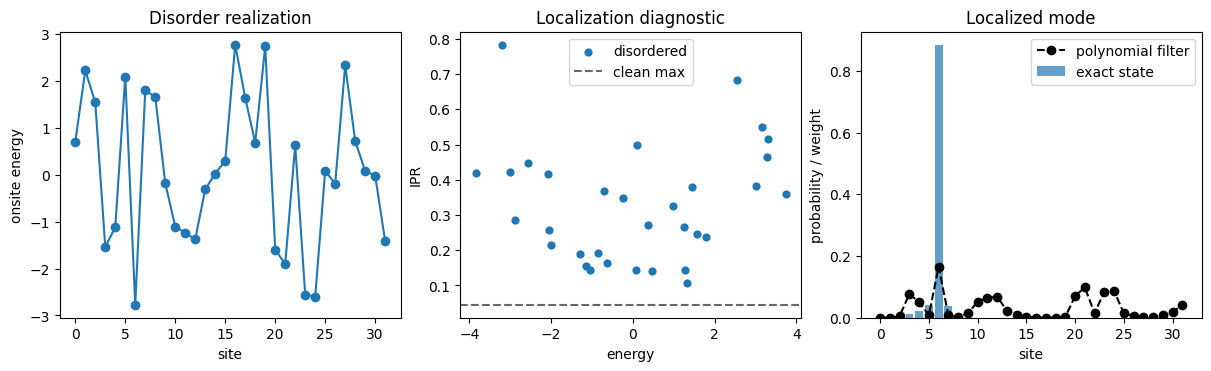

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), constrained_layout=True)

axes[0].plot(np.arange(n_sites), onsite, "o-")
axes[0].set_xlabel("site")
axes[0].set_ylabel("onsite energy")
axes[0].set_title("Disorder realization")

axes[1].scatter(eigenvalues, ipr, s=24, label="disordered")
axes[1].axhline(np.max(clean_ipr), color="0.4", linestyle="--", label="clean max")
axes[1].set_xlabel("energy")
axes[1].set_ylabel("IPR")
axes[1].set_title("Localization diagnostic")
axes[1].legend()

axes[2].bar(
    np.arange(n_sites), np.abs(localized_state) ** 2, alpha=0.7, label="exact state"
)
axes[2].plot(
    np.arange(n_sites), filtered_weight, "o--", color="black", label="polynomial filter"
)
axes[2].set_xlabel("site")
axes[2].set_ylabel("probability / weight")
axes[2].set_title("Localized mode")
axes[2].legend()

plt.show()

## Validation

Compact checks for disorder-induced localization and the energy-window filter.


In [5]:
assert ipr[localized_index] > 0.25
assert ipr[localized_index] > 5.0 * np.max(clean_ipr)
assert filtered_weight[peak_site] > 0.12

print(f"localized_energy: {center_energy:.4f}")
print(f"localized_ipr: {ipr[localized_index]:.4f}")
print(f"clean_max_ipr: {np.max(clean_ipr):.4f}")
print(f"peak_site_filter_weight: {filtered_weight[peak_site]:.4f}")
print("validation: passed")

localized_energy: -3.1990
localized_ipr: 0.7834
clean_max_ipr: 0.0455
peak_site_filter_weight: 0.1654
validation: passed
